In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import re
from PIL.ImageColor import colormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from pathlib import Path

In [3]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if project_root is None:
    raise FileNotFoundError(f"Could not locate project root folder named '{project_folder_name}'.")
print("Project root path:")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from configuration.settings import *
from model.dynamic import PEMFC_dyn
from model.static import PEMFC_stat
from model.coefficients import *
from configuration.initialize import *

Project root path:


In [4]:
I_points = [10, 20, 30, 40, 50]

dyn_sim_log = {}
stat_sim_log = {}

for RHC in [0.5, 0.0]:
    for P_des in [1.3,1.4,1.5]:
        for T_des in [323.15,333.15,343.15]:
            states_dyn = []
            states_stat = []

            for I_LOAD in I_points:
                # --------------- Dynamic Simulation  --------------- #
                operating_inputs["Phi_c_des"] = RHC 
                operating_inputs["Pa_des"] = P_des * 1e5
                operating_inputs["Pc_des"] = P_des * 1e5
                operating_inputs["Tfc"] = T_des
                operating_inputs["current_density"] = lambda x: I_LOAD/parameters["Aact"]
                model = PEMFC_dyn(parameters,operating_inputs, init_x(operating_inputs, parameters))
                sol = solve_ivp(model.dxdt, (0, 60), init_x(operating_inputs, parameters), method='BDF', max_step=1e-1)
                model._recovery(sol)
                # --------------- Log states for dynamic simulation  --------------- #
                states = {}
                for key, var_name in enumerate(model.variables):
                    states[var_name] = model.variables[var_name][-1]
                for key, var_name in enumerate(model.elec_variables):
                    states[var_name] = model.elec_variables[var_name][-1]
                states_dyn.append(states)
                # --------------- Steady-state Simulation  --------------- #
                operating_inputs_stat = operating_inputs.copy()
                operating_inputs_stat = {'Tfc': T_des, 'Phi_a_des': 0, 'Phi_c_des': RHC,
                                                        'Pa_des': P_des * 1e5, 'Pc_des': P_des * 1e5,
                                                        'Win_c': 4.8, 'Wout_c': 22.7, 'Win_a': 4.8, 'Wout_a': 4.8}
                model = PEMFC_stat(parameters,operating_inputs_stat)
                sol = model.solve(I_LOAD/parameters['Aact'])
                # --------------- Log states for steady-state simulation  --------------- #
                states_stat.append(sol)

            # --------------- Log states for both simulations  --------------- #
            states_profile_dyn = {}
            for key, value in enumerate(states_dyn[0].keys()):
                states_profile_dyn[value] = [states[value] for states in states_dyn]
            dyn_sim_log["RHA"+str(0)+"/RHC" + str(RHC) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_profile_dyn}
            stat_sim_log["RHA"+str(0)+"/RHC" + str(RHC) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_stat}

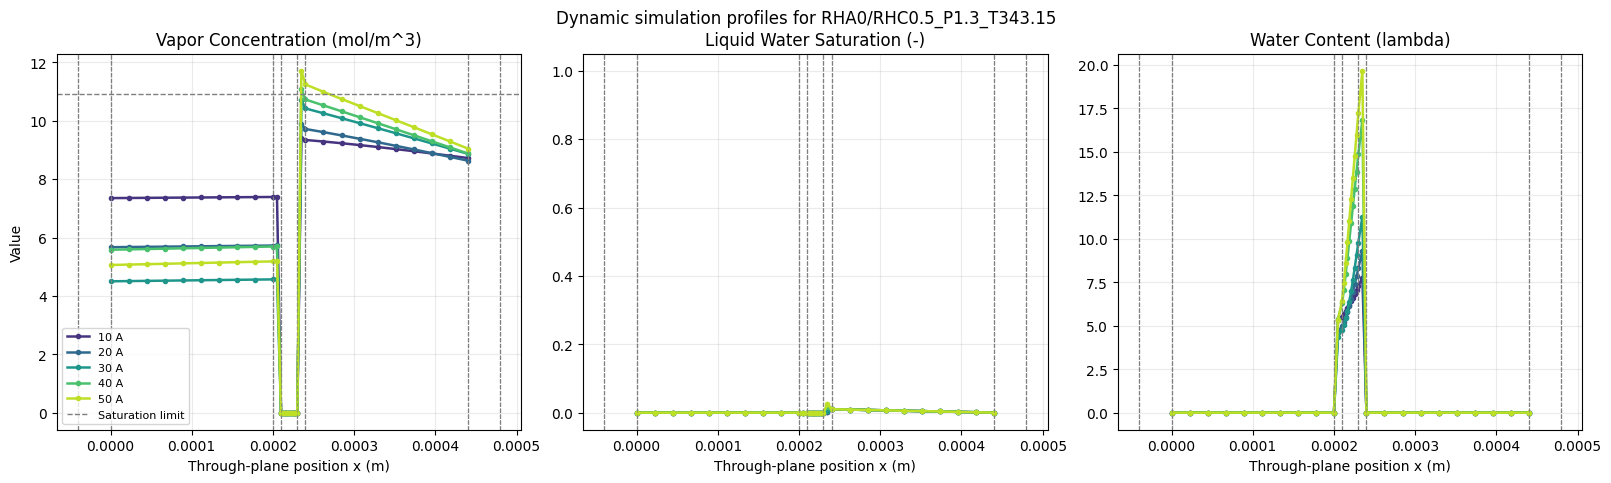

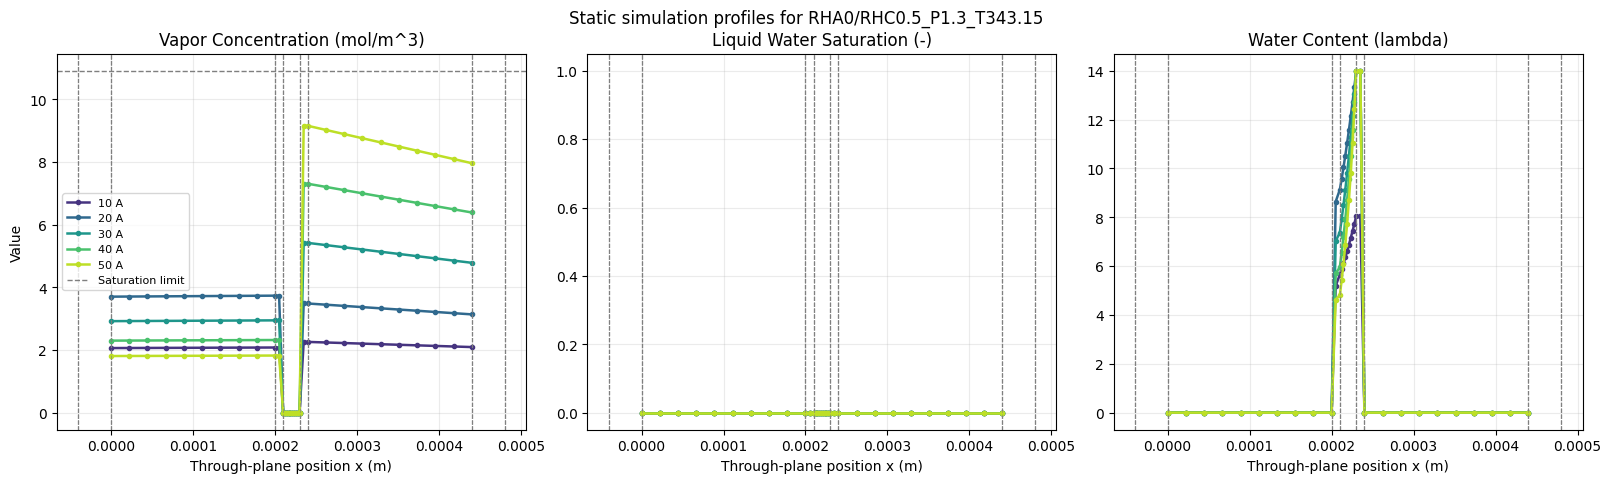

In [17]:
selected_case = list(dyn_sim_log)[2]
dyn_states = dyn_sim_log[selected_case]["states"]
stat_states = stat_sim_log[selected_case]["states"]

temperature_match = re.search(r"_T([0-9.]+)$", selected_case)
if temperature_match is None:
    raise ValueError(f"Could not extract the temperature from '{selected_case}'.")

case_temperature = float(temperature_match.group(1))
plot_nodes = nodes[1:-1]
profile_panels = [
    ("v", "Vapor Concentration (mol/m^3)"),
    ("saturation", "Liquid Water Saturation (-)"),
    ("lambda", "Water Content (lambda)"),
]
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(I_points)))


def build_dynamic_profiles(states_by_variable, current_index):
    return {
        "v": [float(states_by_variable[name][current_index]) for name in nodes_names_vp],
        "saturation": [float(states_by_variable[name][current_index]) for name in nodes_names_s],
        "lambda": [float(states_by_variable[name][current_index]) for name in nodes_lambda],
    }


def build_static_profiles(state):
    saturation_acl = float(state["s_agdl"][-1])
    saturation_ccl = float(state["s_cgdl"][0])
    return {
        "v": list(np.asarray(state["Cv_agdl"])) + [float(state["Cv_acl"]), float(state["Cv_ccl"])] + list(np.asarray(state["Cv_cgdl"])),
        "saturation": list(np.asarray(state["s_agdl"])) + [saturation_acl, saturation_ccl] + list(np.asarray(state["s_cgdl"])),
        "lambda": [float(state["lambda_acl"])] + list(np.asarray(state["lambda_mem"])) + [float(state["lambda_ccl"])],
    }


def plot_profiles(title_prefix, profile_builder):
    fig, axes = plt.subplots(1, len(profile_panels), figsize=(16, 4.5), constrained_layout=True)

    for idx, (current, color) in enumerate(zip(I_points, colors)):
        profiles = profile_builder(idx)
        for ax, (profile_key, title) in zip(axes, profile_panels):
            y_values = expand_profile_on_nodes(profile_key, profiles[profile_key])
            ax.plot(plot_nodes, y_values, marker="o", markersize=3, linewidth=1.8, color=color, label=f"{current} A")
            if profile_key == "saturation":
                ax.set_ylim(-0.05, 1.05)
            for x_border in borders:
                ax.axvline(x=x_border, color="tab:gray", linestyle="--", linewidth=0.8, alpha=0.6)
            ax.set_title(title)
            ax.set_xlabel("Through-plane position x (m)")
            ax.grid(True, alpha=0.25)

    axes[0].axhline(C_v_sat(case_temperature), color="tab:gray", linestyle="--", linewidth=1.0, label="Saturation limit")
    axes[0].set_ylabel("Value")
    axes[0].legend(loc="best", fontsize=8)
    fig.suptitle(f"{title_prefix} profiles for {selected_case}", y=1.04)
    plt.show()


plot_profiles("Dynamic simulation", lambda current_index: build_dynamic_profiles(dyn_states, current_index))
plot_profiles("Static simulation", lambda current_index: build_static_profiles(stat_states[current_index]))

In [13]:
hfr_data_path = project_root / "data" / "HFR.xlsx"
expdata_hfr = pd.read_excel(hfr_data_path, sheet_name=None)

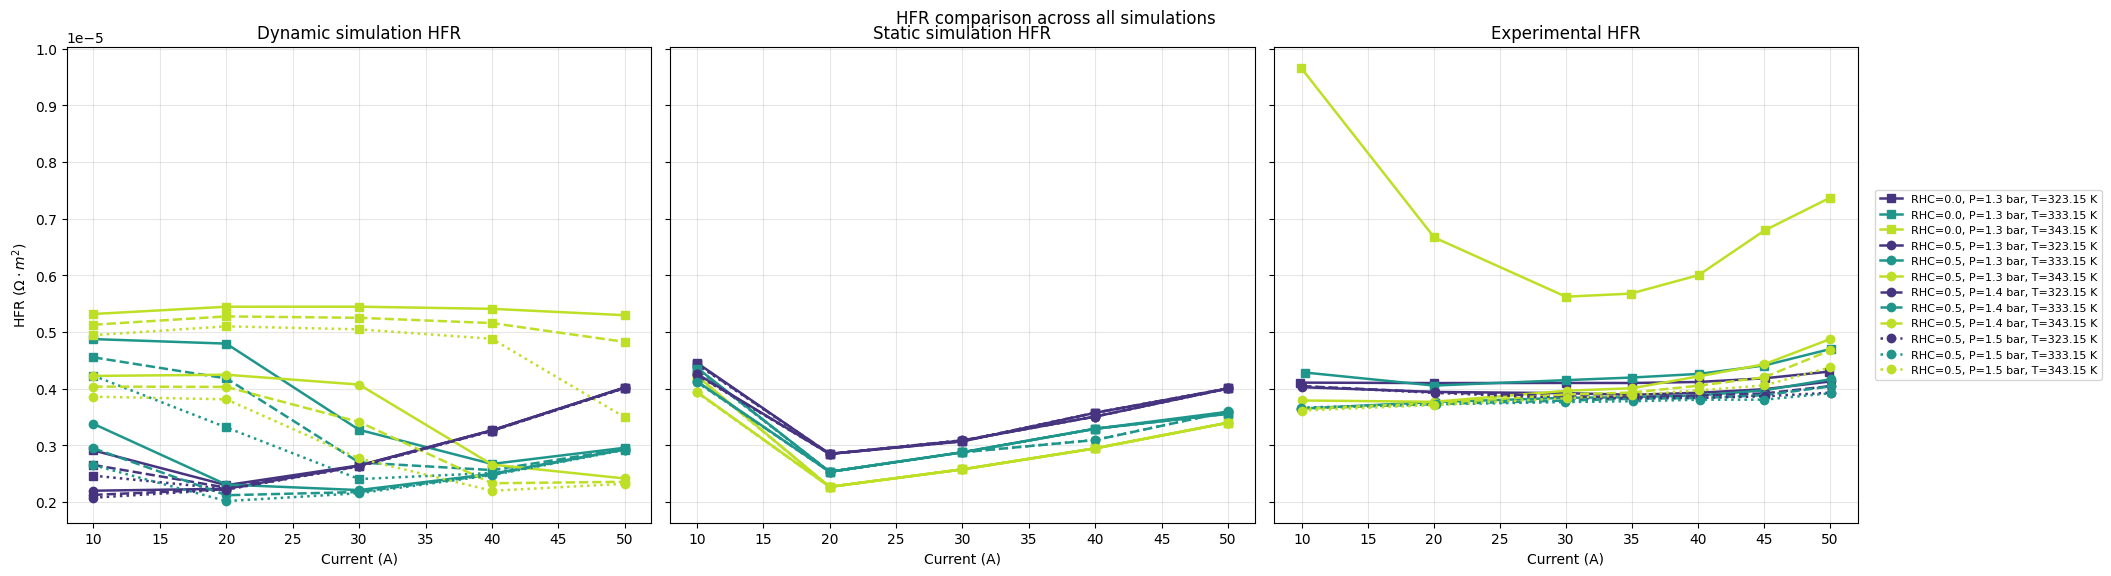

In [15]:
case_keys = list(dyn_sim_log)


def case_to_sheet_name(rhc, pressure_bar, temperature_k):
    temperature_c = int(round(temperature_k - 273.15))
    pressure_code = int(round((pressure_bar - 1.0) * 1000))
    humidity_code = int(round(rhc * 100))
    return f"T{temperature_c}_P{pressure_code}_HRC{humidity_code}"


def parse_experimental_hfr(sheet_data):
    resistance_values = []
    for raw_value in sheet_data["R"]:
        parsed_value = raw_value
        if isinstance(raw_value, str):
            parsed_value = eval(raw_value, {"__builtins__": {}}, {})
        resistance_values.append(float(parsed_value[0]) * 1e-7)
    return pd.DataFrame(
        {
            "current_a": pd.to_numeric(sheet_data["I_LOAD"], errors="coerce"),
            "hfr_ohm_m2": resistance_values,
        }
    ).dropna()


case_metadata = []
for case_key in case_keys:
    rhc_match = re.search(r"RHC([0-9.]+)_P", case_key)
    pressure_match = re.search(r"_P([0-9.]+)_T", case_key)
    temperature_match = re.search(r"_T([0-9.]+)$", case_key)
    if rhc_match is None or pressure_match is None or temperature_match is None:
        raise ValueError(f"Could not extract metadata from '{case_key}'.")

    rhc = float(rhc_match.group(1))
    pressure_bar = float(pressure_match.group(1))
    temperature_k = float(temperature_match.group(1))
    case_metadata.append(
        {
            "case_key": case_key,
            "rhc": rhc,
            "pressure_bar": pressure_bar,
            "temperature_k": temperature_k,
            "sheet_name": case_to_sheet_name(rhc, pressure_bar, temperature_k),
        }
    )

unique_pressures = sorted({item["pressure_bar"] for item in case_metadata})
unique_temperatures = sorted({item["temperature_k"] for item in case_metadata})
line_styles = ["-", "--", ":", "-."]
pressure_styles = {
    pressure: line_styles[index % len(line_styles)] for index, pressure in enumerate(unique_pressures)
}
temp_colors = {
    temperature: color
    for temperature, color in zip(unique_temperatures, plt.cm.viridis(np.linspace(0.15, 0.9, len(unique_temperatures))))
}
humidity_markers = {0.0: "s", 0.5: "o"}

fig, axes = plt.subplots(1, 3, figsize=(21, 5.5), constrained_layout=True, sharey=True)
ax_dynamic, ax_static, ax_exp = axes

for item in sorted(case_metadata, key=lambda entry: (entry["rhc"], entry["pressure_bar"], entry["temperature_k"])):
    dyn_states_case = dyn_sim_log[item["case_key"]]["states"]
    stat_states_case = stat_sim_log[item["case_key"]]["states"]
    dynamic_hfr = np.array([extract_hfr_from_dynamic(value) for value in dyn_states_case["Rmem"]])
    static_hfr = np.array([float(state["Rohm"] - parameters["Re"]) for state in stat_states_case])
    curve_label = f"RHC={item['rhc']:.1f}, P={item['pressure_bar']:.1f} bar, T={item['temperature_k']:.2f} K"
    color = temp_colors[item["temperature_k"]]
    linestyle = pressure_styles[item["pressure_bar"]]
    marker = humidity_markers.get(item["rhc"], "o")

    ax_dynamic.plot(
        I_points,
        dynamic_hfr,
        marker=marker,
        linewidth=1.8,
        color=color,
        linestyle=linestyle,
        label=curve_label,
    )
    ax_static.plot(
        I_points,
        static_hfr,
        marker=marker,
        linewidth=1.8,
        color=color,
        linestyle=linestyle,
        label=curve_label,
    )

    if item["sheet_name"] in expdata_hfr:
        experimental_hfr = parse_experimental_hfr(expdata_hfr[item["sheet_name"]])
        ax_exp.plot(
            experimental_hfr["current_a"],
            experimental_hfr["hfr_ohm_m2"],
            marker=marker,
            linewidth=1.8,
            color=color,
            linestyle=linestyle,
            label=curve_label,
        )

ax_dynamic.set_title("Dynamic simulation HFR")
ax_static.set_title("Static simulation HFR")
ax_exp.set_title("Experimental HFR")

for axis in axes:
    axis.set_xlabel("Current (A)")
    axis.grid(True, alpha=0.3)

ax_dynamic.set_ylabel(r"HFR ($\Omega\cdot m^2$)")
ax_exp.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
fig.suptitle("HFR comparison across all simulations", y=1.02)
plt.show()